In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
df = pd.read_csv("/content/loan_data.csv")

# Basic Information

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df.tail()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [ ]:
df.sample(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
30794,36.0,male,Master,70830.0,14,RENT,9275.0,HOMEIMPROVEMENT,14.72,0.13,16.0,665,Yes,0
14294,25.0,female,Associate,37041.0,1,OWN,3425.0,PERSONAL,6.17,0.09,2.0,582,Yes,0
16012,26.0,female,Master,90970.0,6,MORTGAGE,12500.0,EDUCATION,5.99,0.14,4.0,631,No,0
39085,27.0,male,Bachelor,150854.0,6,MORTGAGE,15628.0,PERSONAL,9.18,0.10,4.0,633,No,0
12358,25.0,female,Bachelor,48571.0,1,RENT,12000.0,VENTURE,5.79,0.25,2.0,668,No,0


In [ ]:
# Number of Columns
num_columns = df.shape[1]
num_columns

14

In [ ]:
# Number of Rows
num_rows = df.shape[0]
num_rows

45000

In [ ]:
df.shape

(45000, 14)

In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

# EDA

In [ ]:
# Missing cells calculation
total_missing = df.isnull().sum().sum()
missing_percentage = (total_missing / (num_columns * num_rows)) * 100

print(f"Total missing value: {total_missing}")
print(f"Total missing value Parcentage: {missing_percentage}")

Total missing value: 0
Total missing value Parcentage: 0.0


In [ ]:
# Duplicate rows
duplicate_rows = df.duplicated().sum()
duplicate_percentage = (duplicate_rows / num_rows) * 100

print(f"Total duplicate rows: {duplicate_rows}")
print(f"Total duplicate rows Parcentage: {duplicate_percentage}")

Total duplicate rows: 0
Total duplicate rows Parcentage: 0.0


In [ ]:
# Unique values check
df.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


In [ ]:
numerical_features = []
categorical_features = []

for column in df.columns:
    if df[column].dtype == "object":
        categorical_features.append(column)
    else:
        numerical_features.append(column)

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Numerical Features (9): ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']
Categorical Features (5): ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [ ]:
import math

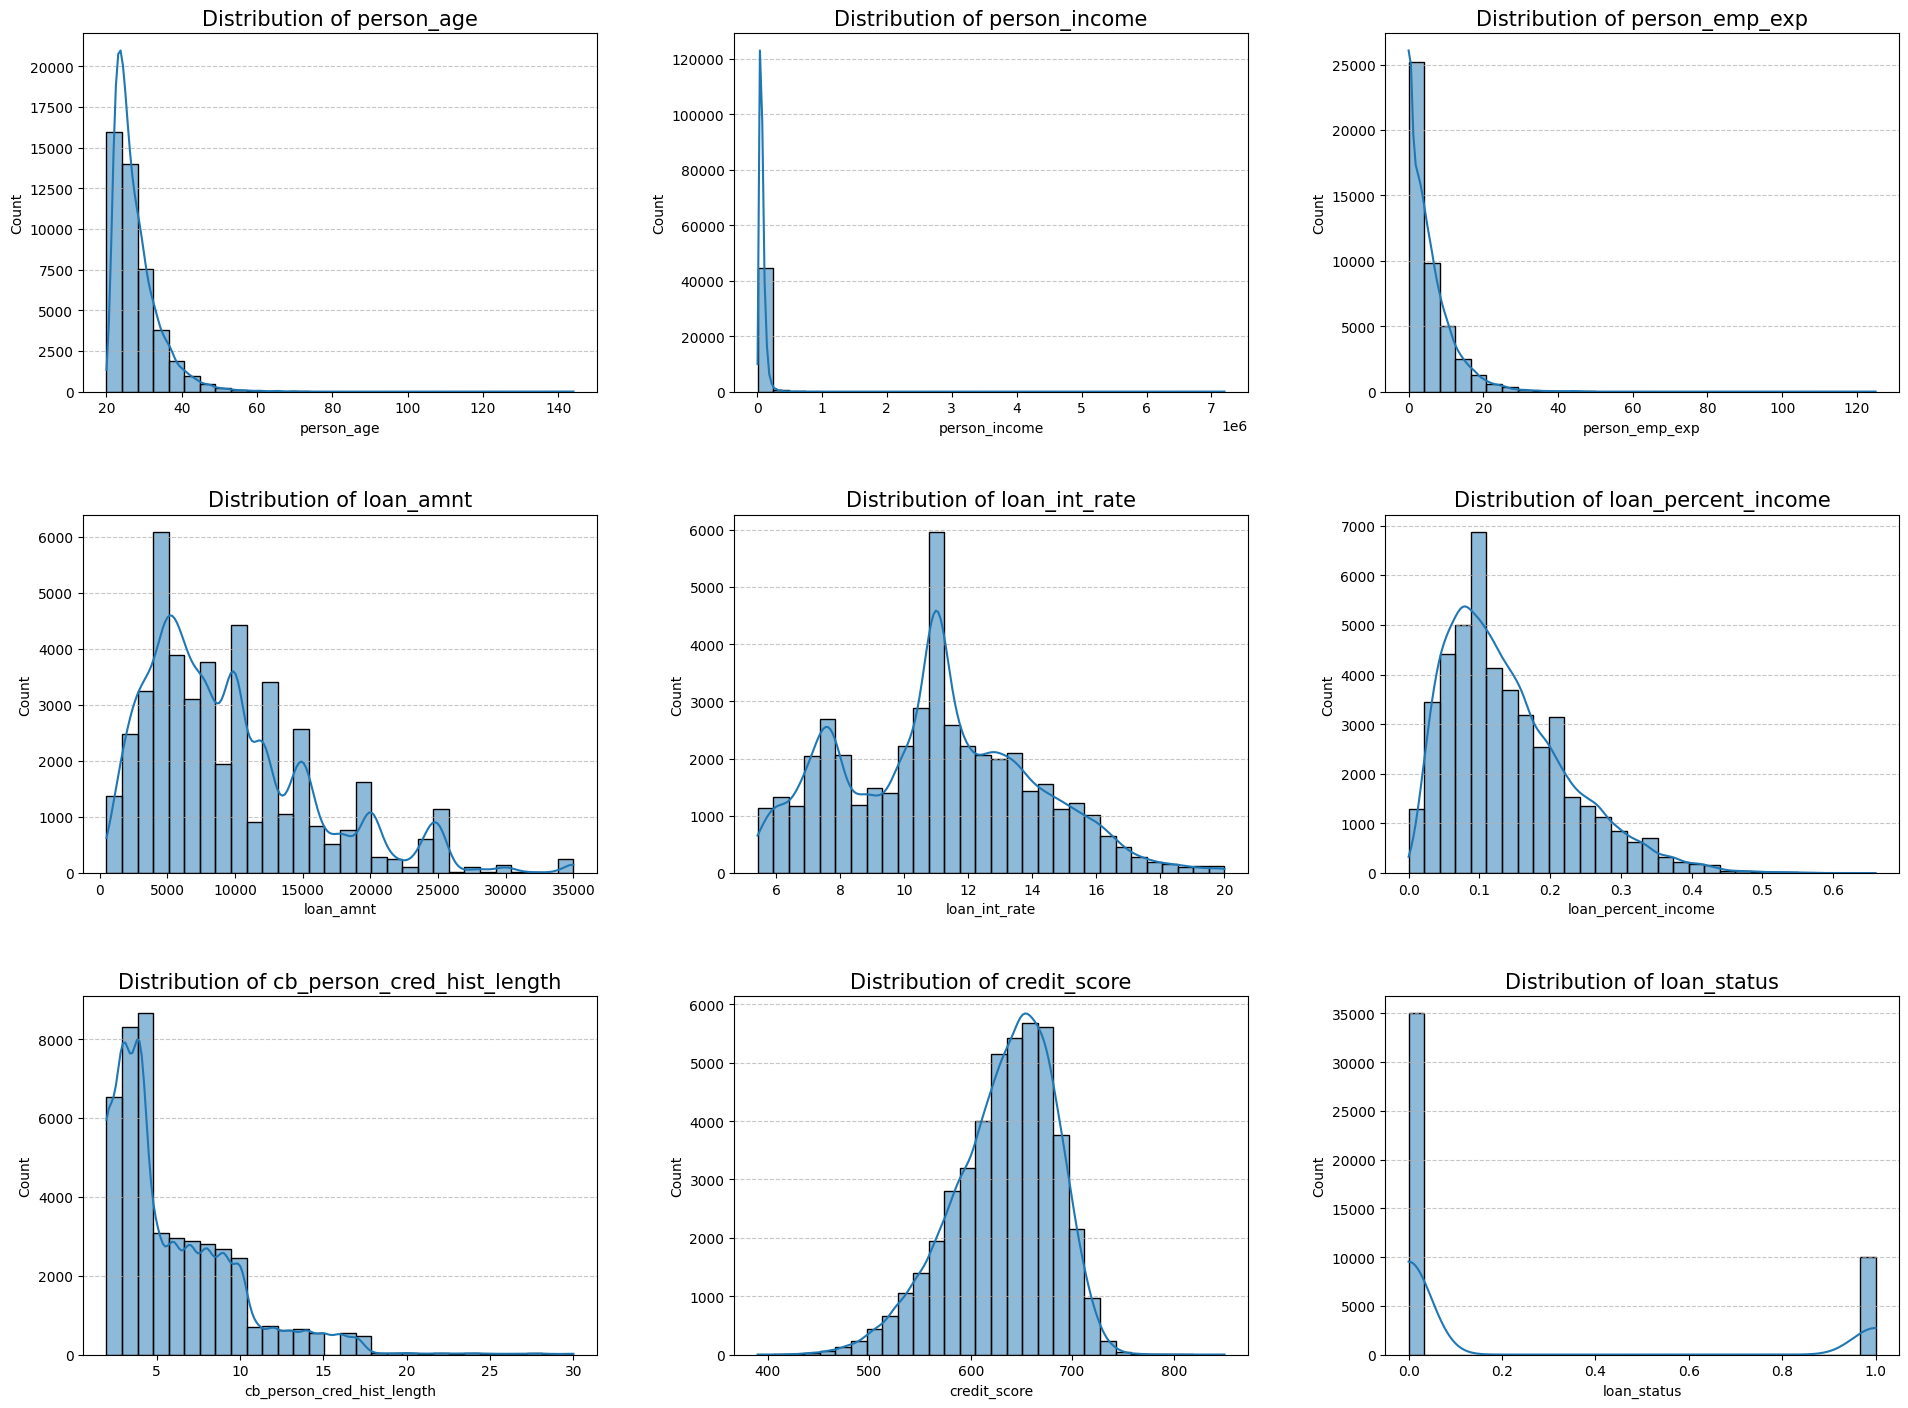

In [ ]:
# Configuration
cols = 3
rows = math.ceil(len(numerical_features) / cols)

plt.figure(figsize=(20, 5 * rows)) # Dynamic Height

for i, col in enumerate(numerical_features, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(pad=4.0)
plt.show()

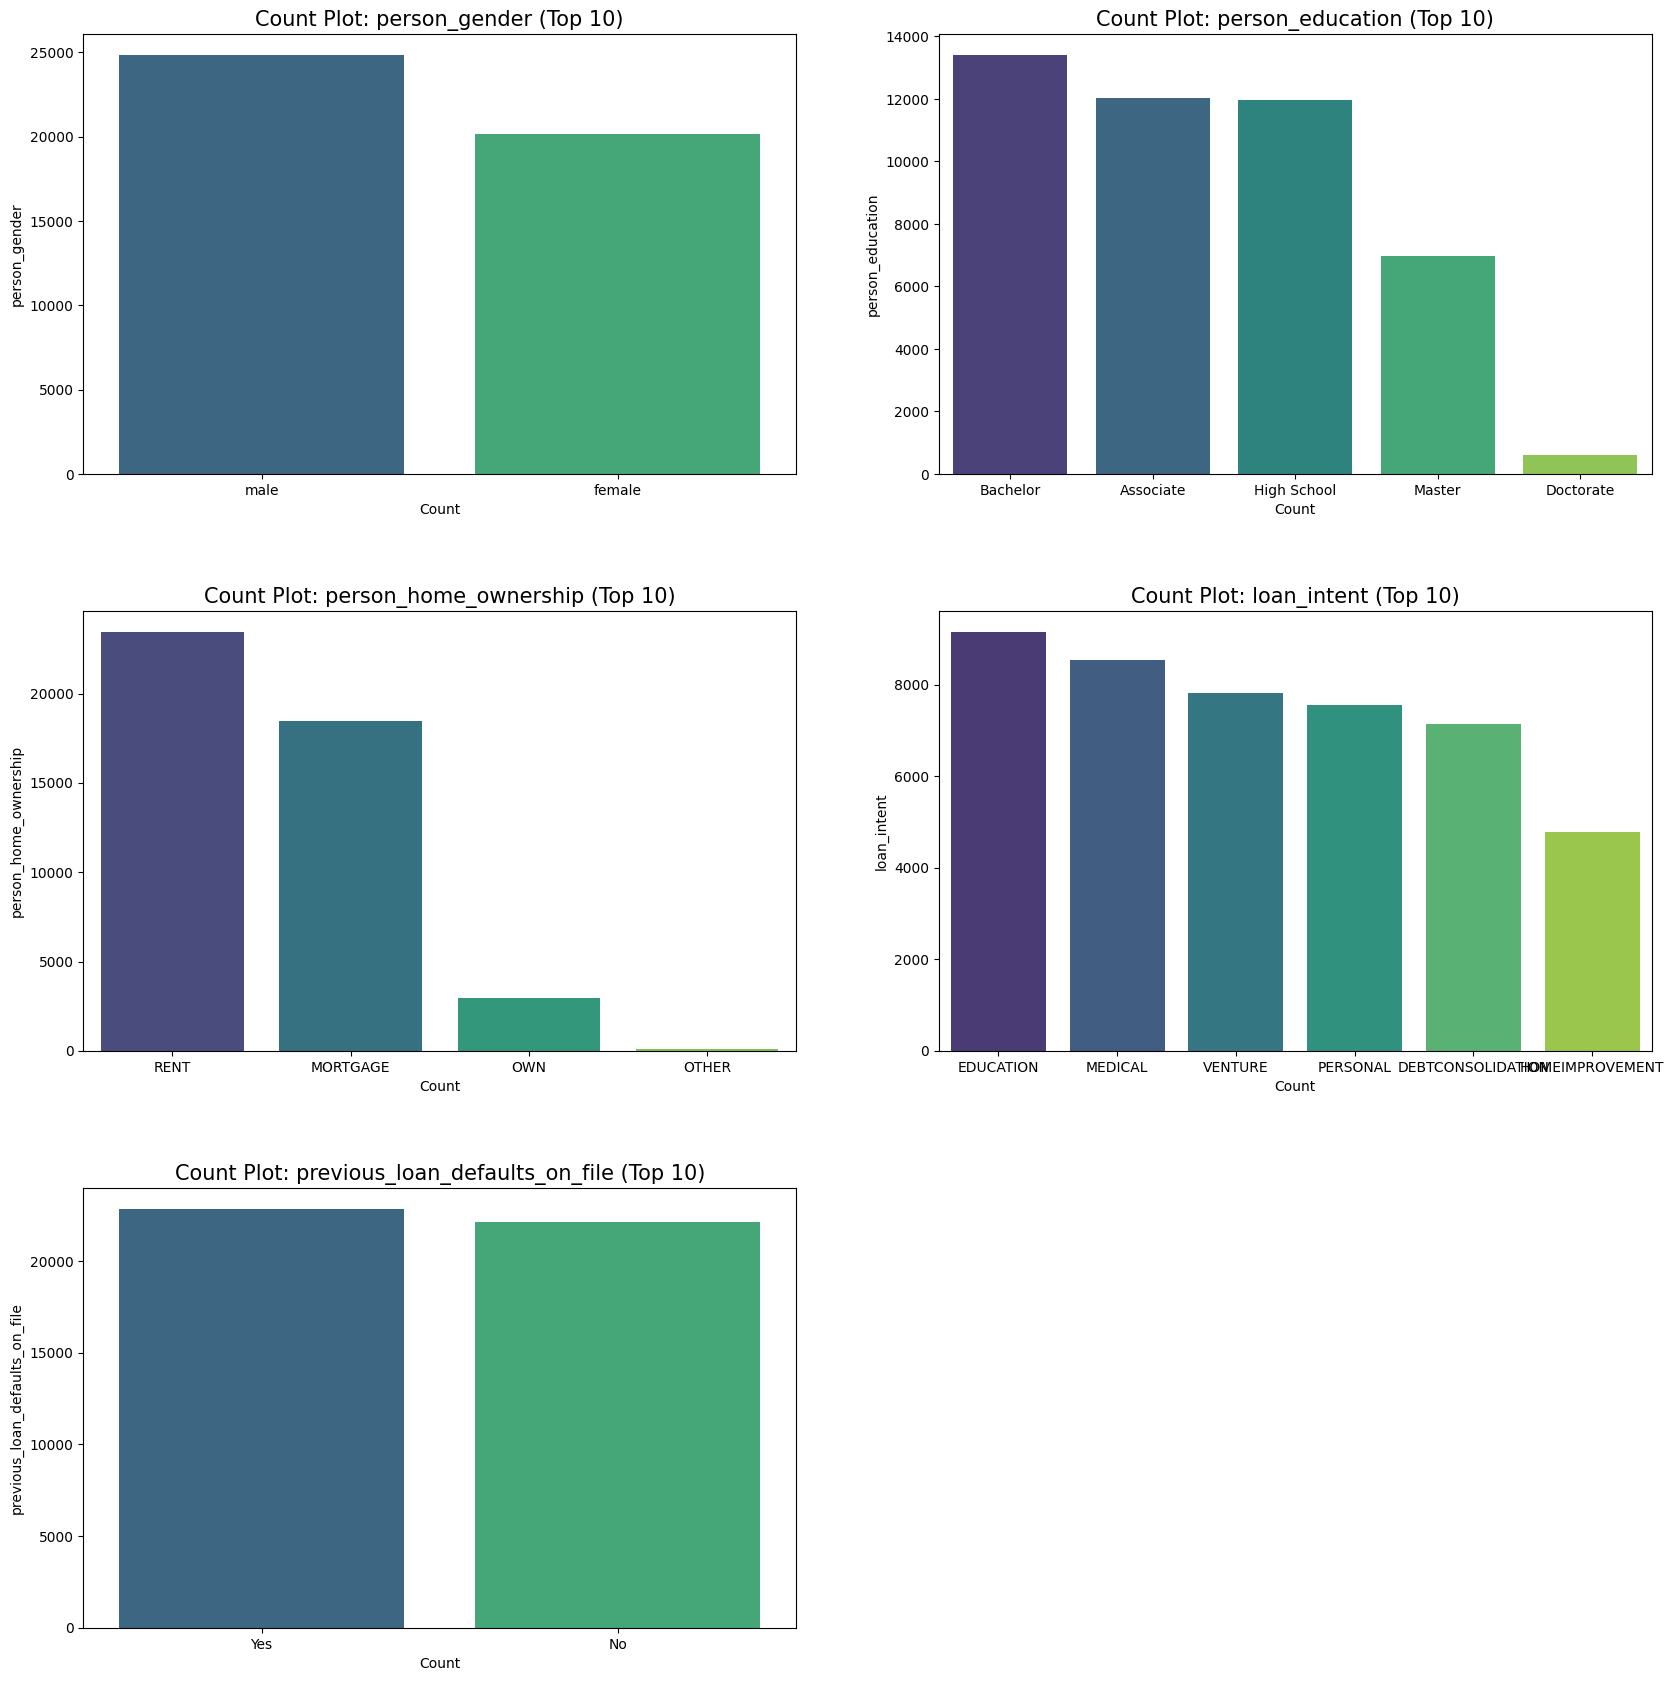

In [ ]:
# Configuration
cols = 2
rows = math.ceil(len(categorical_features) / cols)

plt.figure(figsize=(18, 6 * rows)) # Dynamic Height

for i, col in enumerate(categorical_features, 1):
    plt.subplot(rows, cols, i)

    # Show Top 10 categories if unique value will be huge
    top_n = df[col].value_counts().head(10).index
    sns.countplot(data=df, x=col, order=top_n, palette='viridis')

    plt.title(f'Count Plot: {col} (Top 10)', fontsize=15)
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout(pad=5.0)
plt.show()

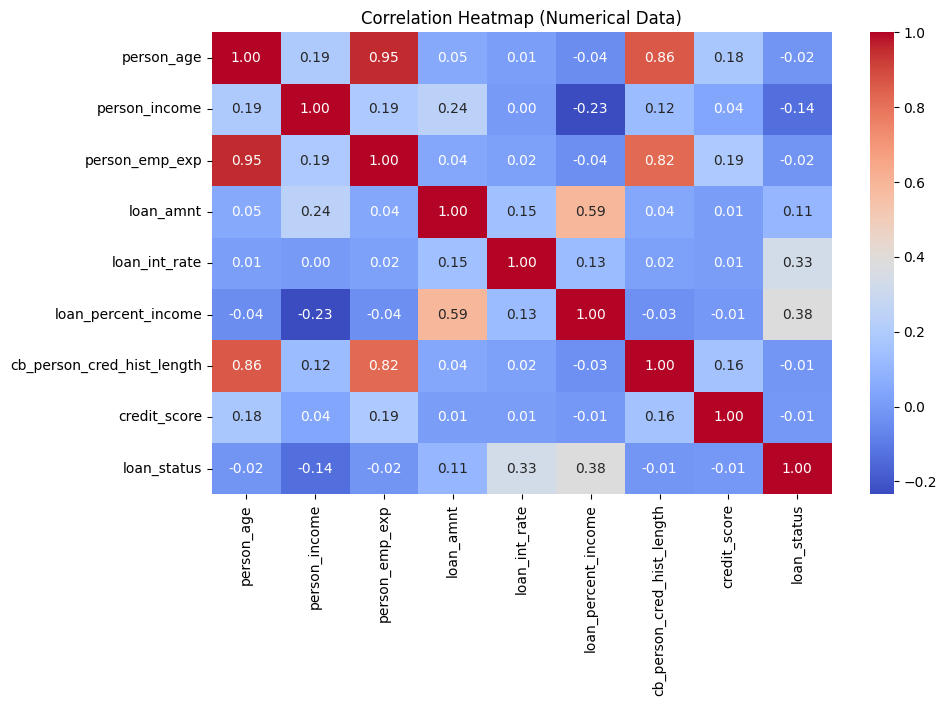

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numerical Data)')
plt.show()

# Feature Engineering

In [ ]:
df.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned["person_gender"].value_counts()

,count
person_gender,
male,24841
female,20159


In [ ]:
df_cleaned['person_gender'] = df_cleaned['person_gender'].map({'male': 1, 'female': 0})

In [ ]:
df_cleaned.rename(columns={
    'person_gender': 'is_male',
}, inplace=True)

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,1,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
df_cleaned["previous_loan_defaults_on_file"].value_counts()

,count
previous_loan_defaults_on_file,
Yes,22858
No,22142


In [ ]:
df_cleaned['previous_loan_defaults_on_file'] = df_cleaned['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

In [ ]:
df_cleaned.rename(columns={
    'previous_loan_defaults_on_file': 'is_previous_loan_defaults_on_file',
}, inplace=True)

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,is_previous_loan_defaults_on_file,loan_status
0,22.0,0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,1,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [ ]:
df.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


In [ ]:
df_cleaned["person_education"].value_counts()

,count
person_education,
Bachelor,13399
Associate,12028
High School,11972
Master,6980
Doctorate,621


In [ ]:
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

df_cleaned['person_education'] = df_cleaned['person_education'].replace({
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
})

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,is_previous_loan_defaults_on_file,loan_status
0,22.0,0,3,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,0,0,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,0,0,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,0,2,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,1,3,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [ ]:
df_cleaned["person_home_ownership"].value_counts()

,count
person_home_ownership,
RENT,23443
MORTGAGE,18489
OWN,2951
OTHER,117


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['person_home_ownership'], prefix='home_ownership', dtype=int)

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,is_previous_loan_defaults_on_file,loan_status,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,22.0,0,3,71948.0,0,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1,0,0,0,1
1,21.0,0,0,12282.0,0,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0,0,0,1,0
2,25.0,0,0,12438.0,3,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1,1,0,0,0
3,23.0,0,2,79753.0,0,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1,0,0,0,1
4,24.0,1,3,66135.0,1,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1,0,0,0,1


In [ ]:
df_cleaned["loan_intent"].value_counts()

,count
loan_intent,
EDUCATION,9153
MEDICAL,8548
VENTURE,7819
PERSONAL,7552
DEBTCONSOLIDATION,7145
HOMEIMPROVEMENT,4783


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['loan_intent'], dtype=int)

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,3,71948.0,0,35000.0,16.02,0.49,3.0,561,...,0,0,0,1,0,0,0,0,1,0
1,21.0,0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,...,0,0,1,0,0,1,0,0,0,0
2,25.0,0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,2,79753.0,0,35000.0,15.23,0.44,2.0,675,...,0,0,0,1,0,0,0,1,0,0
4,24.0,1,3,66135.0,1,35000.0,14.27,0.53,4.0,586,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
df_cleaned['person_age'] = df_cleaned['person_age'].astype(int)
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,0,3,71948.0,0,35000.0,16.02,0.49,3.0,561,...,0,0,0,1,0,0,0,0,1,0
1,21,0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,...,0,0,1,0,0,1,0,0,0,0
2,25,0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,...,1,0,0,0,0,0,0,1,0,0
3,23,0,2,79753.0,0,35000.0,15.23,0.44,2.0,675,...,0,0,0,1,0,0,0,1,0,0
4,24,1,3,66135.0,1,35000.0,14.27,0.53,4.0,586,...,0,0,0,1,0,0,0,1,0,0


#Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
scaler = StandardScaler()
df_cleaned[cols_to_scale] = scaler.fit_transform(df_cleaned[cols_to_scale])

In [ ]:
df_cleaned.head()

,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,-0.953538,0,3,-0.104090,-0.892284,4.024953,1.683039,4.016394,-0.739109,-1.419814,...,0,0,0,1,0,0,0,0,1,0
1,-1.118963,0,0,-0.846005,-0.892284,-1.359209,0.044782,-0.684829,-0.996863,-2.549975,...,0,0,1,0,0,1,0,0,0,0
2,-0.457264,0,0,-0.844065,-0.397517,-0.646600,0.625557,3.443074,-0.739109,0.047412,...,1,0,0,0,0,0,0,1,0,0
3,-0.788113,0,2,-0.007039,-0.892284,4.024953,1.417829,3.443074,-0.996863,0.840507,...,0,0,0,1,0,0,0,1,0,0
4,-0.622689,1,3,-0.176371,-0.727362,4.024953,1.095549,4.475050,-0.481354,-0.924130,...,0,0,0,1,0,0,0,1,0,0


In [ ]:
final_df = df_cleaned.copy()
final_df.head()

,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,-0.953538,0,3,-0.104090,-0.892284,4.024953,1.683039,4.016394,-0.739109,-1.419814,...,0,0,0,1,0,0,0,0,1,0
1,-1.118963,0,0,-0.846005,-0.892284,-1.359209,0.044782,-0.684829,-0.996863,-2.549975,...,0,0,1,0,0,1,0,0,0,0
2,-0.457264,0,0,-0.844065,-0.397517,-0.646600,0.625557,3.443074,-0.739109,0.047412,...,1,0,0,0,0,0,0,1,0,0
3,-0.788113,0,2,-0.007039,-0.892284,4.024953,1.417829,3.443074,-0.996863,0.840507,...,0,0,0,1,0,0,0,1,0,0
4,-0.622689,1,3,-0.176371,-0.727362,4.024953,1.095549,4.475050,-0.481354,-0.924130,...,0,0,0,1,0,0,0,1,0,0


## Data Preparation for Modeling

In [ ]:
X = final_df.drop('loan_status', axis=1)
y = final_df['loan_status']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (45000, 21)
Target shape: (45000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36000, 21)
X_test shape: (9000, 21)
y_train shape: (36000,)
y_test shape: (9000,)


# Train a Predictive Model


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(criterion='gini'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1
    )
}

In [ ]:
trained_models = {}
predictions = {}

# Train all models
for name, model in models.items():

    model.fit(X_train, y_train)

    # Save trained model
    trained_models[name] = model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Store predictions
    predictions[name] = {
        "train_pred": y_train_pred,
        "test_pred": y_test_pred
    }

print("All models trained successfully!")

All models trained successfully!


## Evaluation: Compute Performance Metrics


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Store results
model_list = []
accuracy_list = []

# Evaluate all models
for name in models.keys():

    # Get predictions
    y_train_pred = predictions[name]["train_pred"]
    y_test_pred = predictions[name]["test_pred"]

    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    # Store results
    model_list.append(name)
    accuracy_list.append(test_accuracy)


    print(name)

    print("Model performance for Training set")
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print("- Precision: {:.4f}".format(train_precision))
    print("- Recall: {:.4f}".format(train_recall))
    print("- F1 Score: {:.4f}".format(train_f1))

    print('----------------------------------')

    print("Model performance for Test set")
    print("- Accuracy: {:.4f}".format(test_accuracy))
    print("- Precision: {:.4f}".format(test_precision))
    print("- Recall: {:.4f}".format(test_recall))
    print("- F1 Score: {:.4f}".format(test_f1))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred))

    print("=" * 50)
    print("\n")

Logistic Regression
Model performance for Training set
- Accuracy: 0.8972
- Precision: 0.7794
- Recall: 0.7487
- F1 Score: 0.7637
----------------------------------
Model performance for Test set
- Accuracy: 0.8939
- Precision: 0.7732
- Recall: 0.7428
- F1 Score: 0.7577

Confusion Matrix:
[[6552  438]
 [ 517 1493]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- F1 Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9003
- Precision: 0.7692
- Recall: 0.7910
- F1 Score: 0.7800

Confusion Matrix:
[[6513  477]
 [ 420 1590]]

Classification Rep

# Knowledge Representation

In [ ]:
knowledge_base = final_df.groupby('loan_status').mean()

print("Statistical Knowledge Base (Mean values by Loan Status):")
display(knowledge_base)

Statistical Knowledge Base (Mean values by Loan Status):


,person_age,is_male,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
loan_status,,,,,,,,,,,,,,,,,,,,,
0,0.011479,0.552171,1.383971,0.072592,0.010948,-0.057576,-0.177464,-0.205727,0.007938,0.004088,...,0.4670,0.002229,0.077971,0.4528,0.142343,0.217171,0.100714,0.176286,0.172314,0.191171
1,-0.040178,0.551500,1.381100,-0.254073,-0.038317,0.201515,0.621124,0.720045,-0.027783,-0.014307,...,0.2144,0.003900,0.022200,0.7595,0.216300,0.155200,0.125800,0.237800,0.152100,0.112800


## Reasoning Under Uncertainty: Implementing Bayesian Inference

In [ ]:
import numpy as np
from scipy.stats import norm

def get_gaussian_pdf(x, mean, std):
    """
    Calculates the Probability Density Function (PDF) value for a given x
    assuming a Gaussian distribution.
    """
    if std == 0:
        return 1.0 if x == mean else 0.0
    return norm.pdf(x, loc=mean, scale=std)

def build_bayesian_knowledge_base(X_train, y_train):
    """
    Builds a knowledge base containing prior probabilities and feature statistics
    (mean and std deviation) for each loan status.
    """
    knowledge = {}
    df_train = X_train.copy()
    df_train['loan_status'] = y_train

    # 1. Prior probabilities for loan_status
    total_samples = len(df_train)
    for status in df_train['loan_status'].unique():
        knowledge[f'prior_{status}'] = len(df_train[df_train['loan_status'] == status]) / total_samples

    # 2. Statistics for features per loan_status
    numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

    for status in df_train['loan_status'].unique():
        status_df = df_train[df_train['loan_status'] == status]
        knowledge[f'stats_{status}'] = {}
        for col in numerical_cols:
            knowledge[f'stats_{status}'][col] = {
                'mean': status_df[col].mean(),
                'std': status_df[col].std()
            }
    return knowledge

def bayesian_inference(applicant_data, knowledge_base):
    """
    Performs Bayesian inference to calculate posterior probabilities for each
    loan status given an applicant's data.
    """
    posteriors = {}

    for status in [0, 1]:
        prior = knowledge_base.get(f'prior_{status}', 0.5) # Default to 0.5 if prior not found
        likelihood = 1.0

        # Multiply by likelihood of each feature given the status
        for feature, value in applicant_data.items():
            feature_stats = knowledge_base.get(f'stats_{status}', {}).get(feature)

            if feature_stats and 'mean' in feature_stats and 'std' in feature_stats:
                pdf_value = get_gaussian_pdf(value, feature_stats['mean'], feature_stats['std'])
                likelihood *= pdf_value

        posteriors[status] = prior * likelihood

    # Normalize posteriors to sum to 1
    sum_posteriors = sum(posteriors.values())
    if sum_posteriors == 0:
        # If all likelihoods are zero, return a uniform distribution
        return {0: 0.5, 1: 0.5}

    normalized_posteriors = {status: prob / sum_posteriors for status, prob in posteriors.items()}
    return normalized_posteriors

print("Bayesian inference functions defined successfully!")

Bayesian inference functions defined successfully!


### Demonstration of Bayesian Inference Function

Let's apply our `bayesian_inference` function to an example applicant from the test set.

In [ ]:
# Build the knowledge base using the training data
bayesian_kb = build_bayesian_knowledge_base(X_train, y_train)

# Select an example applicant from the test set (e.g., the first one)
example_applicant = X_test.iloc[0]

print("Example Applicant Data:")
display(example_applicant)

# Perform Bayesian inference
posterior_probabilities = bayesian_inference(example_applicant, bayesian_kb)

print("\nPosterior Probabilities for Example Applicant:")
print(f"P(loan_status=0 | features) (Default): {posterior_probabilities.get(0, 0.0):.4f}")
print(f"P(loan_status=1 | features) (Approved): {posterior_probabilities.get(1, 0.0):.4f}")

# Compare with the actual outcome
actual_status = y_test.iloc[0]
print(f"\nActual Loan Status for Example Applicant: {actual_status}")

Example Applicant Data:


,37979
person_age,0.700710
is_male,1.000000
person_education,1.000000
person_income,0.205740
person_emp_exp,0.756938
loan_amnt,-0.329884
loan_int_rate,-1.667332
loan_percent_income,-0.684829
cb_person_cred_hist_length,1.065174
credit_score,-0.626719



Posterior Probabilities for Example Applicant:
P(loan_status=0 | features) (Default): 0.9923
P(loan_status=1 | features) (Approved): 0.0077

Actual Loan Status for Example Applicant: 0


In [ ]:
from sklearn.metrics import f1_score

# Get posterior probabilities for the entire test set using the Bayesian model
bayesian_probabilities_test = []
for index, row in X_test.iterrows():
    applicant_data = row.to_dict()
    posteriors = bayesian_inference(applicant_data, bayesian_kb)
    bayesian_probabilities_test.append(posteriors.get(1, 0.0)) # Get probability of loan_status=1

# Convert to numpy array
bayesian_probabilities_test = np.array(bayesian_probabilities_test)

# Search for an optimal threshold
thresholds = np.linspace(0.0, 1.0, 100) # Test 100 thresholds between 0 and 1
best_f1 = -1
best_threshold = 0.0

for threshold in thresholds:
    # Make predictions based on the current threshold
    bayesian_y_pred = (bayesian_probabilities_test > threshold).astype(int)

    # Calculate F1-score
    current_f1 = f1_score(y_test, bayesian_y_pred)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"Optimal Threshold found by search: {best_threshold:.4f}")
print(f"F1-score at optimal threshold: {best_f1:.4f}")

# Make final predictions using the optimal threshold
final_bayesian_predictions = (bayesian_probabilities_test > best_threshold).astype(int)

print("\nBayesian Model Performance at Optimal Threshold:")
print(f"Accuracy: {accuracy_score(y_test, final_bayesian_predictions):.4f}")
print(f"Precision: {precision_score(y_test, final_bayesian_predictions):.4f}")
print(f"Recall: {recall_score(y_test, final_bayesian_predictions):.4f}")
print(f"F1-Score: {f1_score(y_test, final_bayesian_predictions):.4f}")

Optimal Threshold found by search: 0.3333
F1-score at optimal threshold: 0.7179

Bayesian Model Performance at Optimal Threshold:
Accuracy: 0.8506
Precision: 0.6206
Recall: 0.8512
F1-Score: 0.7179
